<hr>
<h1 style="text-align: center;">Introduction to Aerodynamics and Python</h1>
<hr>

<h3 style="text-align: center;">Ephraim Aung</h3>
<h3 style="text-align: center;">Student ID: 920074048</h3>
<h3 style="text-align: center;">Project #: 2</h3>
<h3 style="text-align: center;">Date:10/31/2024 </h3>

<h3 style="text-align: center;">EAE 127: Applied Aerodynamics</h3>
<h3 style="text-align: center;">University of California, Davis</h3>

<hr>

In [1]:
#STANDARD IMPORTS
import sympy as sp
import numpy as np
import os
import matplotlib.pyplot as plt
### JUPYTER NOTEBOOK SETTINGS ########################################
#Plot all figures in full-size cells, no scroll bars
%matplotlib inline
#Disable Python Warning Output
#(NOTE: Only for production, comment out for debugging)
import warnings
warnings.filterwarnings('ignore')
### PLOTTING DEFAULTS BOILERPLATE (OPTIONAL) #########################
#SET DEFAULT FIGURE APPERANCE
import seaborn as sns #Fancy plotting package
#No Background fill, legend font scale, frame on legend
sns.set(style='whitegrid', font_scale=1.5, rc={'legend.frameon': True})
#Mark ticks with border on all four sides (overrides 'whitegrid')
sns.set_style('ticks')
#ticks point in
sns.set_style({"xtick.direction": "in","ytick.direction": "in"})
#fix invisible marker bug
sns.set_context(rc={'lines.markeredgewidth': 0.1})
#restore default matplotlib colormap
mplcolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
'#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_palette(mplcolors)

#Get color cycle for manual colors
colors = sns.color_palette()
#SET MATPLOTLIB DEFAULTS
#(call after seaborn, which changes some defaults)
params = {
#FONT SIZES
'axes.labelsize' : 30, #Axis Labels
'axes.titlesize' : 30, #Title
'font.size' : 28, #Textbox
'xtick.labelsize': 22, #Axis tick labels
'ytick.labelsize': 22, #Axis tick labels
'legend.fontsize': 24, #Legend font size
'font.family' : 'serif',
'font.fantasy' : 'xkcd',
'font.sans-serif': 'Helvetica',
'font.monospace' : 'Courier',
#AXIS PROPERTIES
'axes.titlepad' : 2*6.0, #title spacing from axis
'axes.grid' : True, #grid on plot
'figure.figsize' : (8,8), #square plots
'savefig.bbox' : 'tight', #reduce whitespace in saved figures
#LEGEND PROPERTIES
'legend.framealpha' : 0.5,
'legend.fancybox' : True,
'legend.frameon' : True,
'legend.numpoints' : 1,
'legend.scatterpoints' : 1,
'legend.borderpad' : 0.1,
'legend.borderaxespad' : 0.1,
'legend.handletextpad' : 0.2,
'legend.handlelength' : 1.0,
'legend.labelspacing' : 0,
}
import matplotlib
matplotlib.rcParams.update(params) #update matplotlib defaults, call after￿
### END OF BOILERPLATE ##################################################
colors = sns.color_palette() #color cycle

1.0 Superposition of Elementary Flows

Grid Creation

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 250                                         # Number of points/sections to use in each direction for our flow
x_start, x_end = -5.0, 5.0                      # Boundaries of our flow in the x direction 
y_start, y_end = -1.5, 1.5                      # Boundaries of our flow in the y direction 

# Note, you can adjust the start and end points later to get the best image of your plot / flow

x = np.linspace(x_start, x_end, N)              # 1D array of x points
y = np.linspace(y_start, y_end, N)              # 1D array of y points
X, Y = np.meshgrid(x, y)                        # 2D Meshgrid 

Freestream Flow

In [3]:
u_inf = 1.2                                    # Freestream flow velocity

# Computing the freestream velocity field
u_freestream = u_inf * np.ones((N, N), dtype=float)
v_freestream = np.zeros((N, N), dtype=float)

# Computing the stream-function
psi_freestream = u_inf * Y

In [4]:
def get_velocity(strength, xs, ys, X, Y):
    # Here, input the equation for u_source from the equations above
    u = strength / (2 * np.pi) * (X - xs) / ((X - xs)**2 + (Y - ys)**2)

    # Here, input the equation for v_source from the equations above
    v = strength / (2 * np.pi) * (Y - ys) / ((X - xs)**2 + (Y - ys)**2)
    
    return u, v


def get_stream_function(strength, xs, ys, X, Y):
    # Here, input the equation for psi from the equations above
    psi = strength / (2 * np.pi) * np.arctan2((Y - ys), (X - xs))
    
    return psi


Source and Sink in Freestream

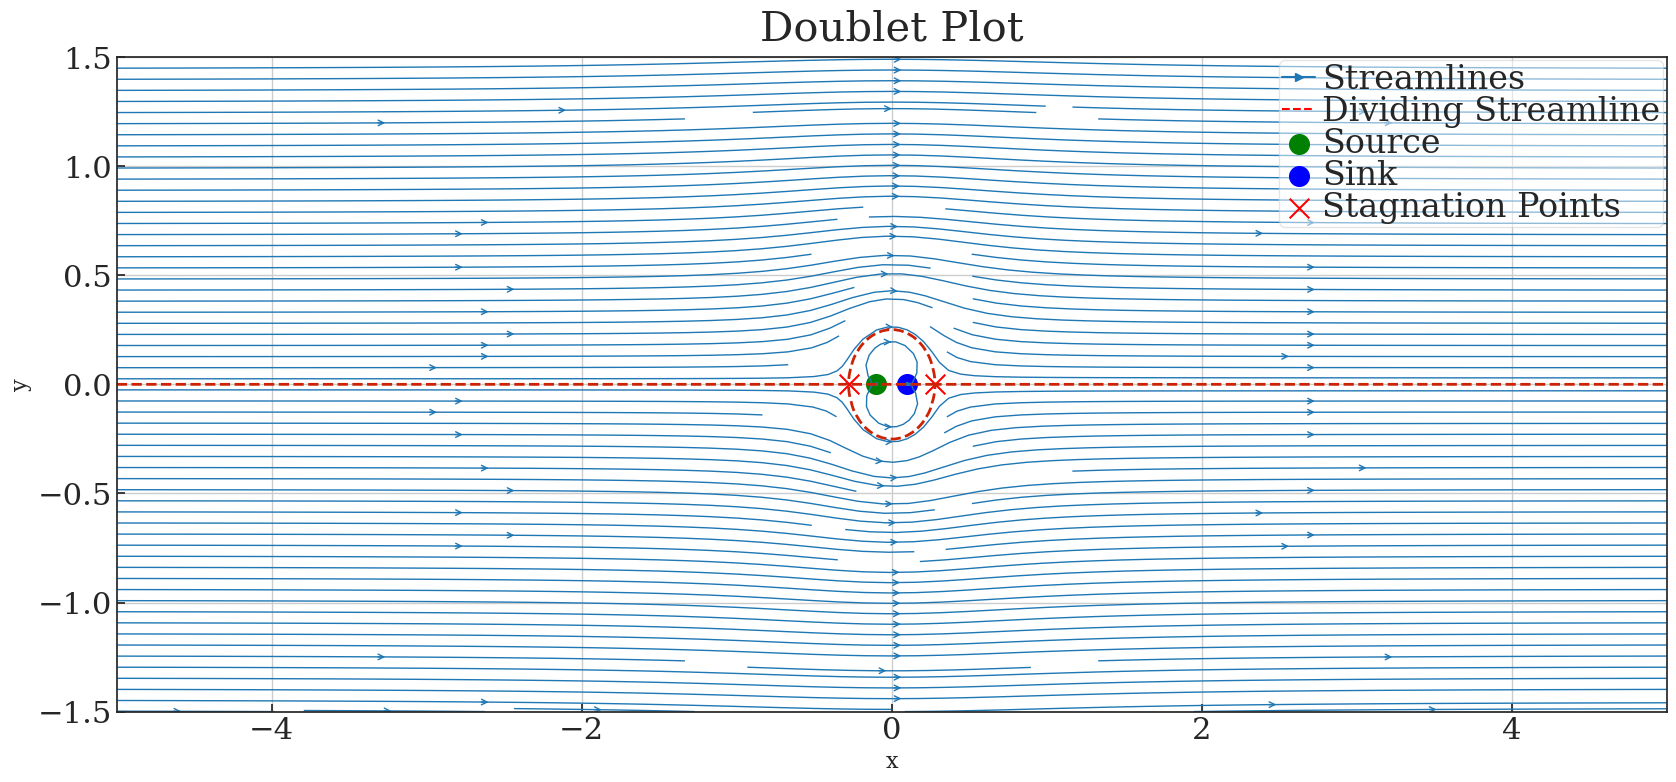

In [5]:

# SOURCE FLOW:
source_strength =  2.5 #[m^2 / s]           # Strength of source singularity
x_source = -0.1                             # X coordinate of source singularity
y_source =  0.0                             # Y coordinate of source singularity        

# Create the Source and Sink contributions to u, v and psi. 
u_source, v_source = get_velocity(source_strength, x_source, y_source, X, Y)
psi_source = get_stream_function(source_strength, x_source, y_source, X, Y)

# SINK FLOW:
sink_strength = -2.5
x_sink = 0.1
y_sink = 0.0

u_sink, v_sink = get_velocity(sink_strength, x_sink, y_source, X, Y)
psi_sink = get_stream_function(sink_strength, x_sink, y_source, X, Y)




# Superposition:
U_Total = u_freestream + u_source + u_sink
V_Total = v_freestream + v_source + v_sink
psi_Total = psi_freestream + psi_source + psi_sink

# The "total" variables now account for the contributions to the flow from both the source and the freestream. 
# This is the Doublet



# PLOTTING:

width = 20
height = 8.5

# Setting up
plt.figure(figsize=(width, height))

plt.grid(True)
plt.title('Doublet Plot')
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
plt.xlim(x_start, x_end)
plt.ylim(y_start, y_end)

# Streamplot is a new plotting function that we will use to display the streamlines. 
# Notice that when plotting the freestream flow, now we should use U_Total and V_Total 
plt.streamplot(X, Y, U_Total, V_Total, density=2, linewidth=1, arrowsize=1, arrowstyle='->')

# A new plotting function we will use is contour(), this creates a contour of the flow. 
# We call this contour the *dividing streamline*. This requires an accurate stream function psi.
plt.contour(X, Y, psi_Total, levels=[0], colors='#CD2305', linewidths=2, linestyles='--')



# LABELING: 
# Streamlines
plt.plot([],[], '->', color='tab:blue', label="Streamlines") # Adding legend label for streamline since streamplot doesn't support "label"

# Dividing Streamline
plt.plot([],[], '--', color='red', label="Dividing Streamline") # Adding legend label for streamline since streamplot doesn't support "label"


# Source and Sink Locations
plt.scatter(x_source, y_source, color = 'green', s = 200, marker ='o', label='Source')
plt.scatter(x_sink, y_sink, color = 'blue', s = 200, marker ='o', label='Sink')

#-----------------------------------------------------------------------------------------------
# Stagnation Point Location 

# Solving Symbolically for Stagnation Point
# Define symbolic variables
x, y = sp.symbols('x y')

# Velocity components for the source and sink
u_freestream = u_inf 
v_freestream = 0
u_source = source_strength / (2 * np.pi) * (x - x_source) / ((x - x_source)**2 + (y - y_source)**2)
v_source = source_strength / (2 * np.pi) * (y - y_source) / ((x - x_source)**2 + (y - y_source)**2)

u_sink = sink_strength / (2 * np.pi) * (x - x_sink) / ((x - x_sink)**2 + (y - y_sink)**2)
v_sink = sink_strength / (2 * np.pi) * (y - y_sink) / ((x - x_sink)**2 + (y - y_sink)**2)

# Total velocity components
U_Total = u_freestream + u_source + u_sink
V_Total = v_freestream + v_source + v_sink

# Set the equations for stagnation point (both velocity components equal to zero)

eq1 = sp.Eq(U_Total, 0)
eq2 = sp.Eq(V_Total, 0)

# Solve the equations
stagnation_point_1 = sp.solve((eq1, eq2), (x, y))
stagnation_point = []

# Get Real Answers and Not Imaginary
for element in stagnation_point_1:
    x = element[0]  
    y = element[1]

    # Check if y is real 
    if x.is_real and y.is_real:
        stagnation_point.append(element)

for point in stagnation_point:
    plt.scatter(point[0], point[1], color = 'red', s = 200, marker ='x')
    
plt.scatter([], [], color='red', s=200, marker='x', label='Stagnation Points') # Label

#-----------------------------------------------------------------------------------------------

plt.legend(loc='upper right')
plt.show()




# You can ignore this part for now. Saving these variables to use later on. 
u_demo = U_Total
v_demo = V_Total
psi_demo = psi_Total 

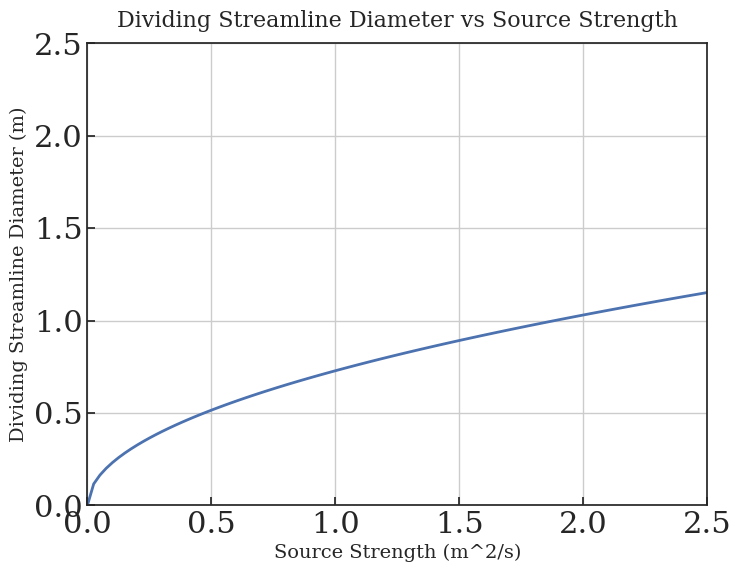

In [6]:


# Freestream velocity (as given in your project)
u_inf = 1.2  # m/s

# Array of source strengths from 0 to 2.5 m^2/s
strengths = np.linspace(0, 2.5, 100)

# Calculate diameters for each strength
diameters = 2 * np.sqrt(strengths / (2 * np.pi * u_inf))

# Plot strength vs diameter
plt.figure(figsize=(8,6))
plt.plot(strengths, diameters, 'b-', linewidth=2)
plt.xlabel('Source Strength (m^2/s)', fontsize=14)
plt.ylabel('Dividing Streamline Diameter (m)', fontsize=14)
plt.title('Dividing Streamline Diameter vs Source Strength', fontsize=16)
plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.grid(True)
plt.show()

The relationship between the Dividing Streamline Diameter and the Source Strength is observed to be logarithmic in nature.

2.0 Potential Flow Airfoil Representation

Generated X Locations: [0.035      0.11570248 0.24326446 0.41768595 0.63896694 0.90710744
 1.22210744 1.58396694 1.99268595 2.44826446 2.95070248 3.5       ]
Generated Strengths: [ 1.3425  1.2405  1.1385  1.0365  0.9345  0.8325 -1.3425 -1.2405 -1.1385
 -1.0365 -0.9345 -0.8325]


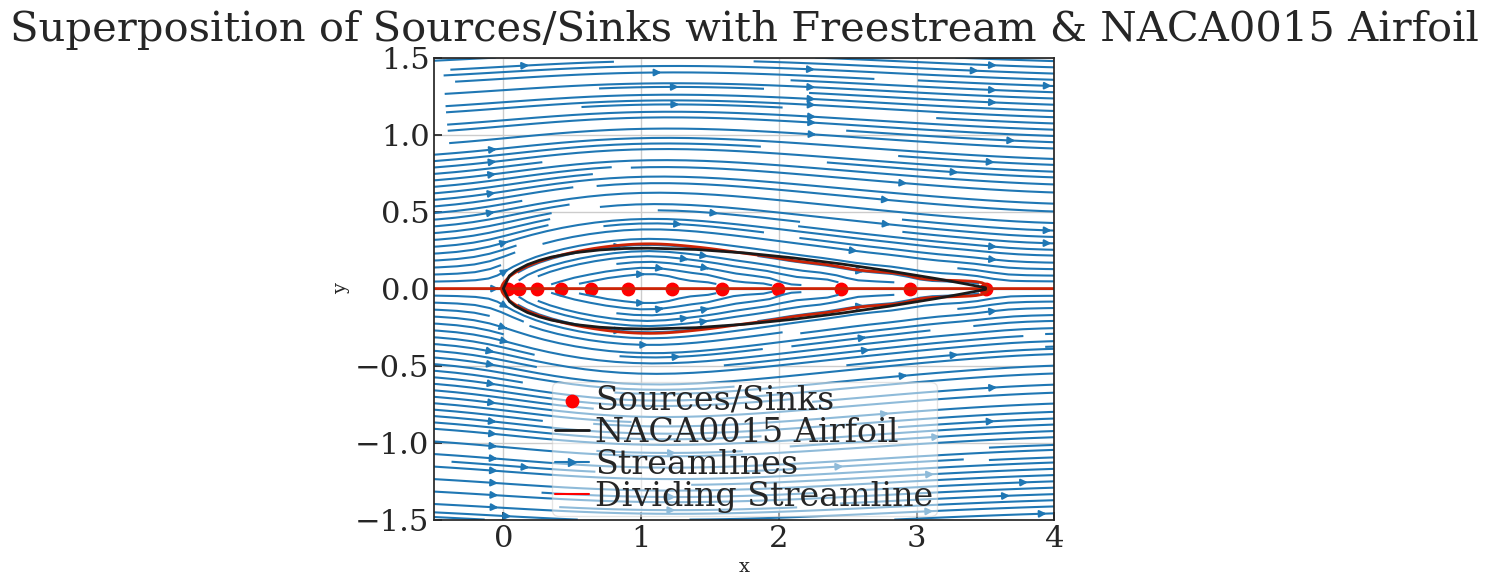

In [7]:
u_inf = 8  # Freestream velocity

# Initialize total/superposition variables
U_Total = u_inf * np.ones_like(X)  # Include freestream in U_Total
V_Total = np.zeros_like(X)         # Freestream has no vertical component initially
psi_Total = u_inf * Y              # Streamfunction for freestream


# Number of sources and sinks
num_sources_sinks = 12
# Strength scaling factor (adjust this to scale all source/sink strengths)
strength_scale = 0.75  # You can change this value to scale the overall strength

# Function to generate x_loc array with heavy distribution at both ends and light in the middle
def generate_x_loc(num_points, chord_length=3.5):

    # Create a non-linear distribution using quadratic spacing
    base_distribution = np.linspace(0.1, 1, num_points)
    
    # Apply a power function to cluster points near 0 and 1 (leading and trailing edges)
    x_loc = chord_length * (base_distribution**2)  # Quadratic distribution
    
    return x_loc

# Automatically generate x_loc array using heavy-on-ends distribution
x_loc = generate_x_loc(num_sources_sinks)

print("Generated X Locations:", x_loc)


# Function to generate strengths that sum to zero
def generate_strengths(num_points):
  
    half_points = num_points // 2
    
    # Generate positive and negative strengths symmetrically
    positive_strengths = np.linspace(1.79, 1.11, half_points)
    negative_strengths = -positive_strengths
    
    return np.concatenate([positive_strengths, negative_strengths])



# Automatically generate strengths for sources/sinks that sum to zero
Strengths = generate_strengths(num_sources_sinks)

# Apply scaling factor to all strengths
Strengths *= strength_scale
print("Generated Strengths:", Strengths)


y_loc = np.zeros_like(x_loc)                             # All y-locations are zero

n = len(Strengths)  # Number of sources/sinks

# Function to calculate velocity field of a source/sink
def get_velocity(strength, xs, ys, X, Y):
    u = strength / (2 * np.pi) * (X - xs) / ((X - xs)**2 + (Y - ys)**2)
    v = strength / (2 * np.pi) * (Y - ys) / ((X - xs)**2 + (Y - ys)**2)
    return u, v

# Function to calculate stream function of a source/sink
def get_stream_function(strength, xs, ys, X, Y):
    psi = strength / (2 * np.pi) * np.arctan2((Y - ys), (X - xs))
    return psi

# Loop through each source/sink and compute its contribution to U_Total, V_Total, and psi_Total
for i in range(n):
    strength = Strengths[i]  # Get current strength
    x_source = x_loc[i]      # Get current x-coordinate of source/sink
    y_source = y_loc[i]      # Get current y-coordinate of source/sink
    
    # Compute velocity components due to current source/sink
    u, v = get_velocity(strength,x_source,y_source,X,Y)
    
    # Compute stream function due to current source/sink
    psi = get_stream_function(strength,x_source,y_source,X,Y)
    
    # Accumulate contributions from each source/sink into total velocity field and stream function
    U_Total += u
    V_Total += v
    psi_Total += psi

### Step: Read and Scale NACA0015 Data ###
filename = "../naca0015.dat.txt"
x_naca, y_naca = np.loadtxt(filename, skiprows = 1, unpack = True)     
chord_length = 3.5   # Scale factor for chord length     
x_naca_scaled = x_naca * chord_length     # Scale x-coordinates by chord length
y_naca_scaled = y_naca * chord_length     # Scale x-coordinates by chord length

### Plotting ###

# Plotting the result (streamlines and dividing streamline)
plt.figure(figsize=(8 ,6))
plt.grid(True)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.xlim(-0.5,4)
plt.ylim(y_start,y_end)

# Plot streamlines using total velocity field
plt.streamplot(X,Y,U_Total,V_Total,density=2.5)

# Plot dividing streamline where psi=0 (this is the line of stagnation points)
plt.contour(X,Y ,psi_Total ,levels=[0], colors='#CD2305', linewidths=2)

# Plot source/sink locations on the graph
plt.scatter(x_loc,y_loc ,color='red', s=80 ,marker='o', label="Sources/Sinks")

# Overlay actual NACA0015 airfoil geometry on top of existing plot 
plt.plot(x_naca_scaled,y_naca_scaled,'k-',linewidth=2,label="NACA0015 Airfoil")

# LABELING: 
# Streamlines
plt.plot([],[], '->', color='tab:blue', label="Streamlines") # Adding legend label for streamline since streamplot doesn't support "label"

# Dividing Streamline
plt.plot([],[], '-', color='red', label="Dividing Streamline") # Adding legend label for streamline since streamplot doesn't support "label"


plt.legend()
plt.title('Superposition of Sources/Sinks with Freestream & NACA0015 Airfoil')
plt.show()






In [8]:
from scipy.interpolate import interp1d

# In order to extract the dividing streamline, we can use the following function. 

def collect_contour(X, Y, psi_Total, xs = 0, xe = 2.625, af = 1):
    if af == 1:
        levels = 0

    plt.figure()
    CS = plt.contour(X, Y, psi_Total, levels=[0], colors='#CD2305', linewidths=2, linestyles='solid')
    P = CS.collections[0].get_paths()[0]
    plt.close()

    V = P.vertices
    
    x_coord = np.array(V[:,0])
    y_coord = np.array(V[:,1])


    # Now we would like to remove the coordinates that aren't relevant. 
    # Since we are dealing with an airfoil, lets assume the airfoil begins at (0,0) for the leading edge.
    # You may need to adjust the valuye of xe depending on 3/4s of the chord. 
    p = len(x_coord)
    
    for i in range(p-1, 0, -1):
        if (x_coord[i] < xs) or (x_coord[i] > xe):
            x_coord = np.delete(x_coord, i)
            y_coord = np.delete(y_coord, i)
    
    y_coord = abs(y_coord)
    return x_coord, y_coord

# The above function will give the coordinates for your dividing streamline. 
# From here you should interpolate these coordinates to a new vector for x and then use the formula provided
# In the problem statement to determine the error for each approximation. 
# The only inputs you need will be X, Y, and the stream function for you airfoil approximation. You should change 
# levels to be equal to 0 in the plt.contour() function within the collect_contour function.

x_div, y_div = collect_contour(X, Y, psi_Total)

### Step: Read and Scale NACA0015 Data ###
filename = "../naca0015.dat.txt"
x_naca, y_naca = np.loadtxt(filename, skiprows = 1, unpack = True) 
x_naca = x_naca[:14]   
y_naca = y_naca[:14]   
chord_length = 3.5   # Scale factor for chord length     
x_naca_scaled = x_naca * chord_length     # Scale x-coordinates by chord length
y_naca_scaled = y_naca * chord_length     # Scale x-coordinates by chord length


lengthscaledy=len(y_div)


array1=y_div
array2=y_naca_scaled

N=14

x1=np.linspace(0,1, len(array1))

interp1=interp1d(x1, array1, kind='linear')

new_x = np.linspace(0,1,N)

new_array1 = interp1(new_x)

error = (1/N)*np.sum(np.abs(new_array1-array2))

print(f"Error: {float(error):.2f}")

Error: 0.12


3.0 Additional Aerodynamics Problems

3.1 Similarity Parameters

In [9]:
import sympy as sp

# Define symbols
V_model, T_model, rho_model, mu_model = sp.symbols('V_model T_model rho_model mu_model')

# Constants
R = 287.05  # Specific gas constant for air in J/(kg·K)
gamma = 1.4  # Ratio of specific heats for air

# Lear Jet conditions at altitude (full-scale)
V_inf_jet = 200  # m/s
rho_inf_jet = 0.414  # kg/m^3
T_inf_jet = 223  # K
mu_inf_jet = 1.457e-5  # Dynamic viscosity (Pa·s)
L_inf_jet = 1.0  # Characteristic length (e.g., chord length)

# Wind tunnel conditions (model)
P_tunnel = 1.01e5  # N/m^2 (atmospheric pressure)
scale_factor = 1/5

# Speed of sound at altitude for Lear Jet
a_inf = sp.sqrt(gamma * R * T_inf_jet)

# Mach number for Lear Jet
M_inf = V_inf_jet / a_inf

# Reynolds number for Lear Jet
Re_inf = (rho_inf_jet * V_inf_jet * L_inf_jet) / mu_inf_jet

# Speed of sound in wind tunnel model
a_model = sp.sqrt(gamma * R * T_model)

# Mach number in wind tunnel model
M_model = V_model / a_model

# Reynolds number in wind tunnel model
L_model = L_inf_jet * scale_factor
Re_model = (rho_model * V_model * L_model) / mu_model

# Ideal gas law for wind tunnel model
P_eqn = P_tunnel - rho_model * R * T_model

# Equivalency relations from problem statement:
mach_relation = M_model - M_inf
reynolds_relation = Re_model - Re_inf
speed_of_sound_relation = a_model / a_inf - sp.sqrt(T_model / T_inf_jet)
viscosity_relation = mu_model / mu_inf_jet - sp.sqrt(T_model / T_inf_jet)

# Equations to solve: Mach number similarity, Reynolds number similarity, ideal gas law, and viscosity relation
equations = [
    mach_relation,
    reynolds_relation,
    P_eqn,
    viscosity_relation
]

# Initial guesses for the variables [V_model, T_model, rho_model, mu_model]
initial_guesses = {V_model: V_inf_jet * scale_factor, 
                   T_model: T_inf_jet + 50,
                   rho_model: P_tunnel / (R * (T_inf_jet + 50)),
                   mu_model: mu_inf_jet}

# Solve the system of equations using SymPy's nsolve function
solutions = sp.nsolve(equations, [V_model, T_model, rho_model, mu_model], list(initial_guesses.values()))

# Extract and print solutions
V_solution, T_solution, rho_solution, mu_solution = solutions

print(f"Velocity: {float(V_solution):.2f} m/s")
print(f"Temperature: {float(T_solution):.2f} K")
print(f"Density: {float(rho_solution):.4f} kg/m^3")

Velocity: 174.61 m/s
Temperature: 169.98 K
Density: 2.0700 kg/m^3


3.2 Lift Coefficient

In [10]:
#Boeing 787 CL=?
#alt=42,000 ft
W=502500
Rho=0.0005315
V=823
S=4058

CL=(2*W)/(Rho*(V**2)*S)
print(f"Coefficient of Lift: {float(CL):.2f}")


Coefficient of Lift: 0.69
